# Multi-variable Southern Ocean Analysis

This notebook is the broadest example in the tutorial set. It combines several stages of an ocean-data workflow: loading files, checking dimensions and coordinates, selecting a study region, calculating summaries, and creating maps or time-based figures.

## How the pieces connect

A variable is first represented as a labelled array or table. Spatial selection and aggregation turn the raw observations into a quantity that can be plotted. The plotting code then communicates one of three things: where values occur, how they change with time, or how two variables vary together.

## How to interpret the output

For every figure, identify:

- the variable and physical meaning;
- the units and whether the values are raw, averaged, anomalous, or normalized;
- the time window and spatial region;
- the colour scale, axis limits, and missing-value treatment.

Use the maps to inspect spatial structure, line plots to inspect temporal change, and scatter or comparison plots to inspect association between variables. Matching time periods and grids is essential before drawing conclusions across CHL, PAR, MLD, wind, or other environmental variables. The original data paths may need to be edited for your local machine.

In [1]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.lines import Line2D
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

In [4]:
%run antarctic_map.py

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
# Define the color map
color_values = [
    [147,0,108], [111,0,144], [72,0,183], [33,0,222], [0,10,255], [0,74,255],
    [0,144,255], [0,213,255], [0,255,215], [0,255,119], [0,255,15], [96,255,0],
    [200,255,0], [255,235,0], [255,183,0], [255,131,0], [255,79,0], [255,31,0],
    [230,0,0], [165,0,0], [105,0,0]
]
sample_values = [0.0105927390978, 0.01511153517746066, 0.02218493234759939,
                 0.03259381777070279, 0.047886418593687446, 0.06831451603621097,
                 0.10029112852033921, 0.1473464383750438, 0.2164794954661175,
                 0.30882852380362497, 0.4533847704508146, 0.6661070836975002,
                 0.9786359751581525, 1.3961169989723918, 2.049610500045872,
                 3.011261431529367, 4.424106633340013, 6.311407543621453,
                 9.265646919990738, 13.612969492356, 20.0]
cmap = colors.ListedColormap(np.array(color_values)/255.0)
norm = colors.BoundaryNorm(sample_values, len(sample_values))

## Inspect the multi-variable inputs

These cells load the analysis inputs and inspect their dimensions, coordinates, and metadata. This is where you verify that the variables can be compared meaningfully.

In [5]:
ds_mean=xr.open_dataset('/so_data/Revised_data/ds_mean_CHL_1998_2023.nc')
ds_cv=xr.open_dataset('/so_data/Revised_data/CV.nc')

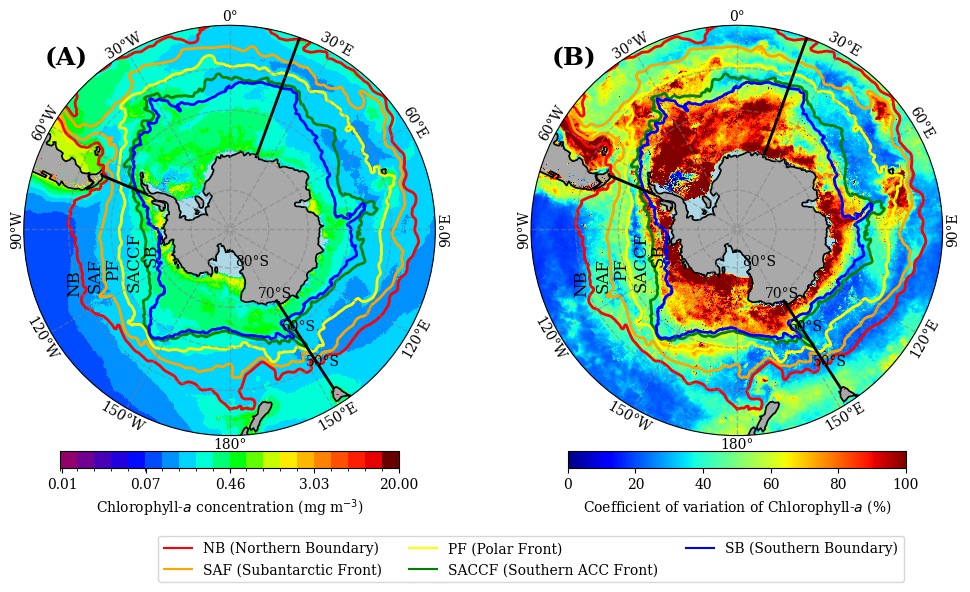

In [50]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
import numpy as np

# Set font properties
plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"

plt.figure(figsize=(12, 6.5))

# Create the first subplot
plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
ax1 = plt.gca()
ax1 = antarctic_map(ax1)
im1 = ax1.pcolormesh(ds_mean.lon, ds_mean.lat, ds_mean.CHL.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Customize colorbar for the first subplot
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8, pad=0.03, orientation='horizontal')
cbar1.ax.set_xlabel('Chlorophyll-${a}$ concentration (mg m$^{-3}$)')
tick_locs = [0.011, 0.07, 0.46, 3.03, 20]
tick_labels = [f"{loc:.2f}" for loc in tick_locs]
cbar1.set_ticks(tick_locs)
cbar1.set_ticklabels(tick_labels)
ax1.text(0.05, 0.95, '(A)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the second subplot
plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
ax2 = plt.gca()
ax2 = antarctic_map(ax2)
im2 = ax2.pcolormesh(ds_cv.lon, ds_cv.lat, ds_cv.CHL.values, cmap='jet', vmin=0, vmax=100, transform=ccrs.PlateCarree())

# Customize colorbar for the second subplot
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.03, orientation='horizontal')
cbar2.ax.set_xlabel('Coefficient of variation of Chlorophyll-${a}$ (%)')
ax2.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')

# Define legend lines and labels
l_stf = Line2D([0], [0], color='red')
l_saf = Line2D([0], [0], color='orange')
l_pf = Line2D([0], [0], color='yellow')
l_saccf = Line2D([0], [0], color='green')
l_sbdy = Line2D([0], [0], color='blue')

labels = ['NB (Northern Boundary)', 'SAF (Subantarctic Front)', 
          'PF (Polar Front)', 'SACCF (Southern ACC Front)', 'SB (Southern Boundary)']

# Add legend with adjusted position
plt.legend(
    [l_stf, l_saf, l_pf, l_saccf, l_sbdy], 
    labels, 
    ncol=3, frameon=True,
    loc=10,  bbox_to_anchor=(0.0, -0.3, 0.0, 0.0),
)

# Adjust layout and save the figure
#plt.tight_layout()  # Optional: comment out if it disrupts the figure
plt.savefig('/so_data/Revised_data/figure_2.jpg', dpi=600)
plt.show()

## Select the study region and prepare fields

This block applies spatial or temporal selections and prepares arrays for plotting. Track which variable is active and whether the operation is a selection, average, anomaly, or normalization.

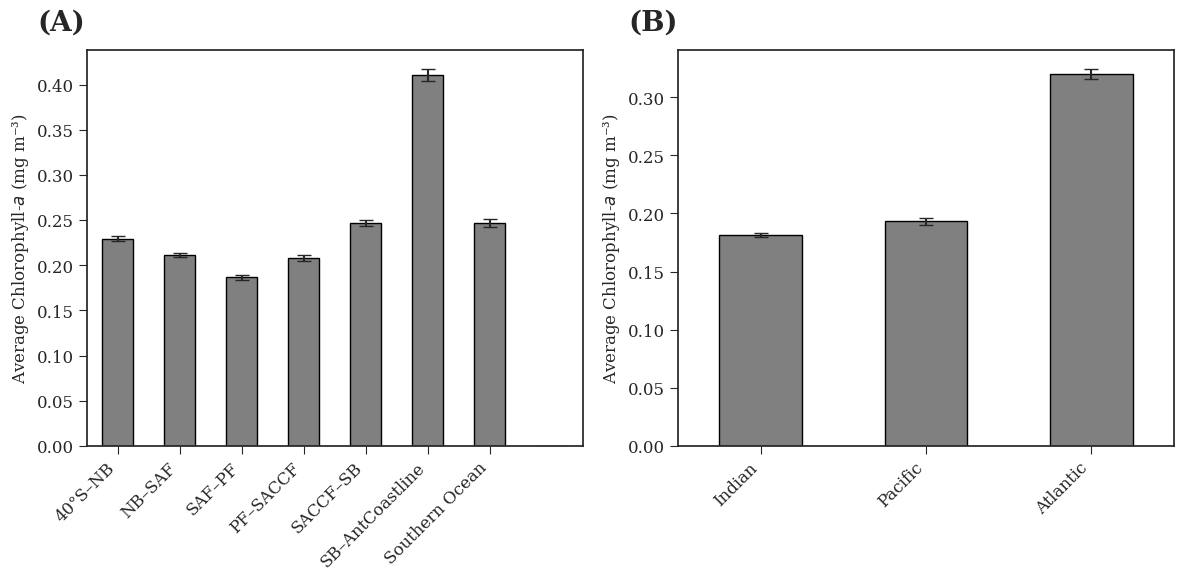

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
df = pd.read_csv('./fronts.csv')
df1 = pd.read_csv('/A04/so_data/Revised_data/IO_PO_AO_section_of_SO_2023.csv')
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12

# Create the second figure with two subplots (B and C)
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 6))

# Second subplot (B)
df.set_index('time', inplace=True)
means1 = df.mean(axis=0)
stds1 = df.std(axis=0) / 17.66  # Std/root n
means1.plot(kind='bar', ax=ax2, yerr=stds1, color='grey', edgecolor='black', capsize=5)

ax2.set_ylabel('Average Chlorophyll-${a}$ (mg m⁻³)')

# Define custom labels for x-axis
labels = ['40°S–NB', 'NB–SAF', 'SAF–PF', 'PF–SACCF', 'SACCF–SB', 'SB–AntCoastline', 'Southern Ocean']
ax2.set_xticks(range(len(labels)))  # Set the ticks based on the number of bars
ax2.set_xticklabels(labels, rotation=45, ha='right')  # Set custom labels with rotation

# Add label for the subplot
ax2.text(-0.1, 1.05, '(A)', transform=ax2.transAxes, fontsize=20, fontweight='bold')


# Third subplot (C)
df1.set_index('time', inplace=True)
means2 = df1.mean(axis=0)
stds2 = df1.std(axis=0) / 17.66

# Bar plot with custom colors
colors = ['gray', 'gray', 'gray']
means2.plot(kind='bar', ax=ax3, yerr=stds2, 
            color=colors, edgecolor='black', capsize=5)

# Create custom legend using mpatches.Rectangle
# handles = [mpatches.Rectangle((0, 0), 1, 1, color=color) for color in colors]
# labels = ['IO (Indian Ocean)', 'PO (Pacific Ocean)', 'AO (Atlantic Ocean)']

# # Add legend inside the plot
# legend = ax3.legend(handles, labels, ncol=1, frameon=True, loc='upper right',
#                     bbox_to_anchor=(0.6, 1.0), fancybox=True, framealpha=0.8)
# legend.get_frame().set_facecolor('white')
labels = ['Indian', 'Pacific', 'Atlantic']
ax3.set_xticks(range(len(labels)))  # Set the ticks based on the number of bars
ax3.set_xticklabels(labels, rotation=45, ha='right')  # Set custom labels with rotation

ax3.set_ylabel('Average Chlorophyll-${a}$ (mg m⁻³)')

ax3.text(-0.1, 1.05, '(B)', transform=ax3.transAxes, fontsize=20, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Number of samples per frontal region:
40S-NB             312
NB_SAF             312
SAF_PF             312
PF_SACCF           280
SACCF_SB           243
SB_AntCoastline    128
Southern Ocean     254
Unnamed: 8           0
dtype: int64

Number of samples per ocean basin:
IO    312
PO    312
AO    312
dtype: int64


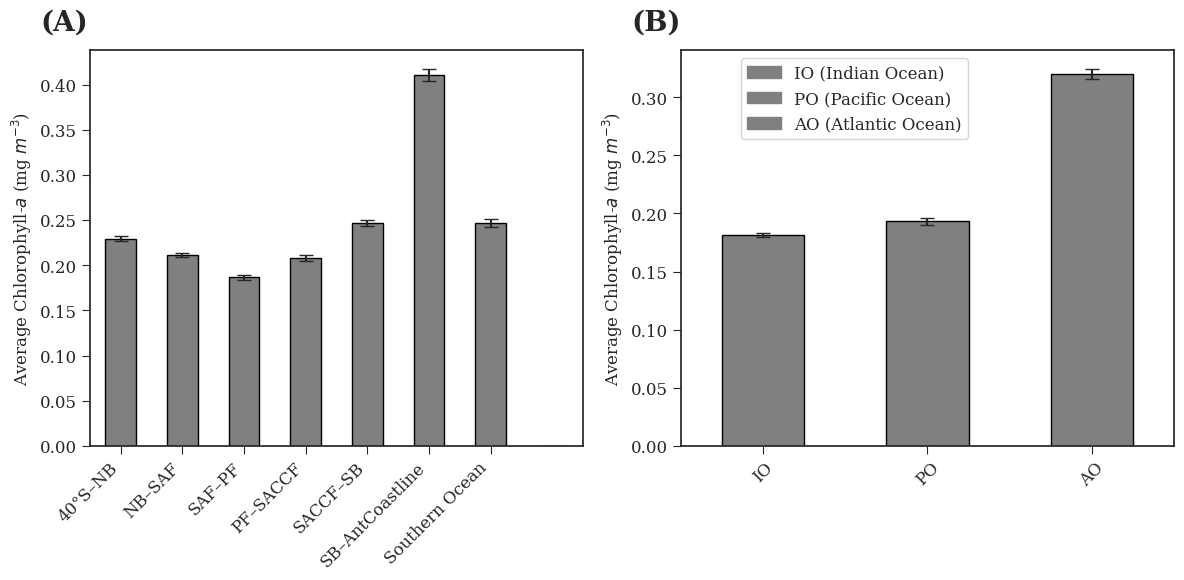

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load data
df = pd.read_csv('./fronts.csv')
df1 = pd.read_csv('/A04/so_data/Revised_data/IO_PO_AO_section_of_SO_2023.csv')

# Set plot styles
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12

# Set up figure and subplots
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 6))

# === Subplot A ===
df.set_index('time', inplace=True)

# Count and print number of samples per region
sample_counts1 = df.count()
print("Number of samples per frontal region:")
print(sample_counts1)

means1 = df.mean(axis=0)
stds1 = df.std(axis=0) / 17.66  # assuming fixed root-n denominator

# Plot with error bars
means1.plot(kind='bar', ax=ax2, yerr=stds1, color='grey', edgecolor='black', capsize=5)
ax2.set_ylabel('Average Chlorophyll-${a}$ (mg $m^{-3}$)')

# Custom x-axis labels
labels = ['40°S–NB', 'NB–SAF', 'SAF–PF', 'PF–SACCF', 'SACCF–SB', 'SB–AntCoastline', 'Southern Ocean']
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')

# Subplot label
ax2.text(-0.1, 1.05, '(A)', transform=ax2.transAxes, fontsize=20, fontweight='bold')

# === Subplot B ===
df1.set_index('time', inplace=True)

# Count and print number of samples per basin
sample_counts2 = df1.count()
print("\nNumber of samples per ocean basin:")
print(sample_counts2)

means2 = df1.mean(axis=0)
stds2 = df1.std(axis=0) / 17.66

# Custom color bar plot
colors = ['gray', 'gray', 'gray']
means2.plot(kind='bar', ax=ax3, yerr=stds2, 
            color=colors, edgecolor='black', capsize=5)

# Custom legend
handles = [mpatches.Rectangle((0, 0), 1, 1, color=color) for color in colors]
labels = ['IO (Indian Ocean)', 'PO (Pacific Ocean)', 'AO (Atlantic Ocean)']
legend = ax3.legend(handles, labels, ncol=1, frameon=True, loc='upper right',
                    bbox_to_anchor=(0.6, 1.0), fancybox=True, framealpha=0.8)
legend.get_frame().set_facecolor('white')

ax3.set_ylabel('Average Chlorophyll-${a}$ (mg $m^{-3}$)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.text(-0.1, 1.05, '(B)', transform=ax3.transAxes, fontsize=20, fontweight='bold')

# Layout and display
plt.tight_layout()
plt.show()

In [2]:
df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
df

,time,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean
0,31/01/1998,0.216398,0.224614,0.208406,0.249688,0.260803,0.496370,0.326782
1,28/02/1998,0.218153,0.200553,0.162206,0.183465,0.210515,0.435724,0.277568
2,31/03/1998,0.206011,0.204145,0.156548,0.155480,0.189952,0.294024,0.216499
3,30/04/1998,0.199581,0.191527,0.157928,0.155041,0.157428,0.204129,0.176325
4,31/05/1998,0.172245,0.170177,0.147406,0.139465,0.141889,0.151725,0.153198
...,...,...,...,...,...,...,...,...
307,31/08/2023,0.160348,0.147546,0.148140,0.150953,0.170122,0.206183,0.156286
308,30/09/2023,0.191858,0.174154,0.154787,0.153830,0.159733,0.153467,0.159362
309,31/10/2023,0.274263,0.246151,0.186206,0.178126,0.174896,0.176384,0.194722
310,30/11/2023,0.296175,0.266264,0.296966,0.306150,0.239961,0.234622,0.270200


In [9]:
# df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
df = pd.read_csv('./fronts.csv')
df['time'] = pd.to_datetime(df['time'])
df['Month'] = df['time'].dt.month
# Extract the month information from the date
monthly_avg = df.groupby('Month').mean()
monthly_avg

,time,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean,Unnamed: 8
Month,,,,,,,,,
1,2010-08-01 12:00:00.000000000,0.264570,0.252202,0.209616,0.257249,0.310703,0.536724,0.357814,NaN
2,2010-08-29 17:32:18.461538560,0.256631,0.237859,0.172191,0.201186,0.278133,0.470523,0.313007,NaN
3,2010-09-29 17:32:18.461538560,0.234232,0.217311,0.163336,0.175773,0.230009,0.349354,0.250039,NaN
4,2010-10-29 17:32:18.461538560,0.210645,0.191561,0.154470,0.164614,0.199434,0.247147,0.193814,NaN
5,2010-11-29 17:32:18.461538560,0.191472,0.176951,0.157152,0.156582,0.168636,NaN,0.164148,NaN
6,2010-12-29 17:32:18.461538560,0.178370,0.176674,0.163750,0.197987,NaN,NaN,NaN,NaN
7,2011-01-29 17:32:18.461538560,0.172042,0.162737,0.162166,0.169867,NaN,NaN,0.162175,NaN
8,2011-03-01 17:32:18.461538560,0.175342,0.157681,0.154484,0.166153,0.181204,NaN,0.163813,NaN
9,2011-03-31 17:32:18.461538560,0.213387,0.180475,0.160393,0.173416,0.189598,NaN,0.173934,NaN


In [20]:
df = pd.read_csv('./fronts.csv')
df['time'] = pd.to_datetime(df['time'])
df['Month'] = df['time'].dt.month
# Calculate number of samples (non-NaN values) for each region and month
monthly_n = df.groupby('Month').count()

# If you only want columns relevant to Chl-a regions (not 'time' or 'Month')
monthly_n = monthly_n[['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean']]

# Print to check
print("Number of samples (n) per month and region:")
print(monthly_n)

Number of samples (n) per month and region:
       40S-NB  NB_SAF  SAF_PF  PF_SACCF  SACCF_SB  SB_AntCoastline  \
Month                                                                
1          26      26      26        26        26               26   
2          26      26      26        26        26               26   
3          26      26      26        26        26               26   
4          26      26      26        26        26               16   
5          26      26      26        26         9                0   
6          26      26      26         1         0                0   
7          26      26      26        19         0                0   
8          26      26      26        26        26                0   
9          26      26      26        26        26                0   
10         26      26      26        26        26                0   
11         26      26      26        26        26                8   
12         26      26      26        26       

In [16]:
import pandas as pd

# Load data
df = pd.read_csv('./fronts.csv')

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'])

# Extract the month
df['Month'] = df['time'].dt.month

# Group by month and calculate mean, min, and max
monthly_stats = df.groupby('Month').agg(['mean', 'min', 'max'])

# Display the result
monthly_stats

time                          40S-NB            \
                               mean        min        max      mean       min   
Month                                                                           
1     2010-08-01 12:00:00.000000000 1998-01-31 2023-01-31  0.264570  0.204581   
2     2010-08-29 17:32:18.461538560 1998-02-28 2023-02-28  0.256631  0.198091   
3     2010-09-29 17:32:18.461538560 1998-03-31 2023-03-31  0.234232  0.186373   
4     2010-10-29 17:32:18.461538560 1998-04-30 2023-04-30  0.210645  0.182462   
5     2010-11-29 17:32:18.461538560 1998-05-31 2023-05-31  0.191472  0.168322   
6     2010-12-29 17:32:18.461538560 1998-06-30 2023-06-30  0.178370  0.151685   
7     2011-01-29 17:32:18.461538560 1998-07-31 2023-07-31  0.172042  0.150260   
8     2011-03-01 17:32:18.461538560 1998-08-31 2023-08-31  0.175342  0.158745   
9     2011-03-31 17:32:18.461538560 1998-09-30 2023-09-30  0.213387  0.184521   
10    2011-05-01 17:32:18.461538560 1998-10-31 2023-10-31  0.268264  0.217696   
11    2011-05-31 17:32:18.461538560 1998-11-30 2023-11-30  0.300131  0.234042   
12    2011-07-01 17:32:18.461538560 1998-12-31 2023-12-31  0.287749  0.234323   

                   NB_SAF                        SAF_PF  ...  SACCF_SB  \
            max      mean       min       max      mean  ...       max   
Month                                                    ...             
1      0.383170  0.252202  0.212371  0.321156  0.209616  ...  0.390996   
2      0.354299  0.237859  0.199024  0.312919  0.172191  ...  0.362141   
3      0.288463  0.217311  0.177268  0.285629  0.163336  ...  0.284196   
4      0.256690  0.191561  0.164601  0.239414  0.154470  ...  0.255791   
5      0.232117  0.176951  0.147155  0.235312  0.157152  ...  0.186997   
6      0.212912  0.176674  0.150989  0.217252  0.163750  ...       NaN   
7      0.204360  0.162737  0.144051  0.202358  0.162166  ...       NaN   
8      0.199659  0.157681  0.146127  0.181560  0.154484  ...  0.215982   
9      0.255522  0.180475  0.154008  0.213561  0.160393  ...  0.228431   
10     0.322029  0.227525  0.187182  0.276759  0.185212  ...  0.296929   
11     0.373232  0.268547  0.212860  0.311746  0.258697  ...  0.391087   
12     0.372179  0.289253  0.242003  0.355191  0.299376  ...  0.413385   

      SB_AntCoastline                     Southern Ocean                      \
                 mean       min       max           mean       min       max   
Month                                                                          
1            0.536724  0.403951  0.703362       0.357814  0.302256  0.446361   
2            0.470523  0.391320  0.625572       0.313007  0.276885  0.375612   
3            0.349354  0.270250  0.505151       0.250039  0.214030  0.325076   
4            0.247147  0.203242  0.306160       0.193814  0.167319  0.239001   
5                 NaN       NaN       NaN       0.164148  0.138565  0.207582   
6                 NaN       NaN       NaN            NaN       NaN       NaN   
7                 NaN       NaN       NaN       0.162175  0.159174  0.165177   
8                 NaN       NaN       NaN       0.163813  0.144190  0.192688   
9                 NaN       NaN       NaN       0.173934  0.151716  0.197435   
10                NaN       NaN       NaN       0.208098  0.179444  0.240815   
11           0.254536  0.211814  0.355943       0.271565  0.240818  0.320702   
12           0.436440  0.298423  0.626733       0.351783  0.289626  0.414851   

      Unnamed: 8          
            mean min max  
Month                     
1            NaN NaN NaN  
2            NaN NaN NaN  
3            NaN NaN NaN  
4            NaN NaN NaN  
5            NaN NaN NaN  
6            NaN NaN NaN  
7            NaN NaN NaN  
8            NaN NaN NaN  
9            NaN NaN NaN  
10           NaN NaN NaN  
11           NaN NaN NaN  
12           NaN NaN NaN  

[12 rows x 27 columns]

In [13]:
df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
#df = pd.read_csv('./fronts.csv')
df['time'] = pd.to_datetime(df['time'])
df['Month'] = df['time'].dt.month
# Extract the month information from the date
monthly_avg = df.groupby('Month').mean()
monthly_avg

,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean
Month,,,,,,,
1,0.257553,0.252218,0.209616,0.257250,0.310702,0.536722,0.357822
2,0.248218,0.237856,0.172191,0.201186,0.278139,0.470522,0.313011
3,0.226460,0.217308,0.163336,0.175773,0.230019,0.349352,0.250040
4,0.203020,0.191563,0.154470,0.164614,0.199435,0.248029,0.193814
5,0.185120,0.176953,0.157152,0.156582,0.175046,0.207912,0.168495
6,0.173669,0.176674,0.163750,0.180807,0.206224,0.216726,0.173708
7,0.167187,0.162739,0.162166,0.171308,0.194955,0.204662,0.167045
8,0.170104,0.157684,0.154484,0.166153,0.181203,0.185627,0.163814
9,0.206962,0.180481,0.160393,0.173416,0.189598,0.177772,0.173934


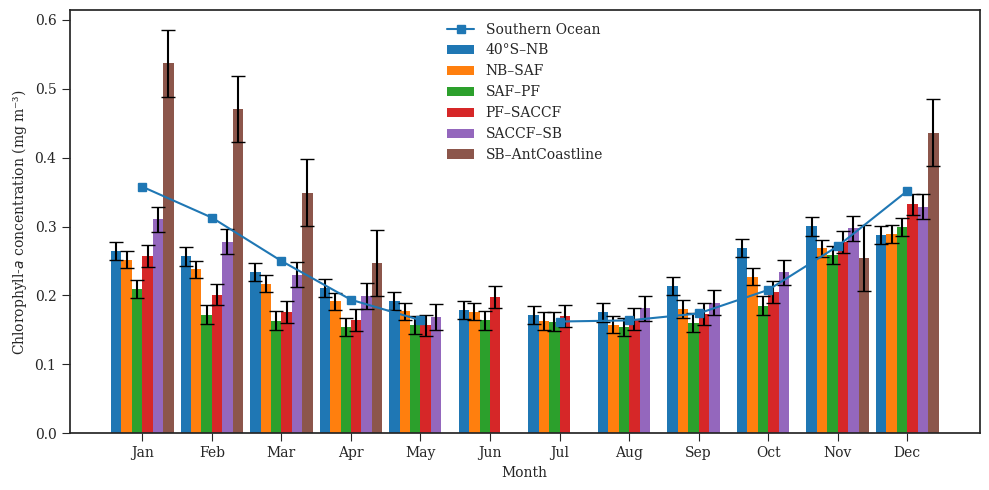

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ... your existing code for data preparation and plotting ...
import matplotlib.pyplot as plt
import numpy as np
# Set plot style
plt.style.use("seaborn-v0_8-ticks")

# Set the figure size to maximum width and transparent background
fig = plt.figure(figsize=(10, 5), facecolor='none')
plt.rcParams['font.family'] = 'Serif'

# Set font to Times New Roman
plt.rcParams['font.size'] = 10
# Define custom month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Define the data to plot
data = monthly_avg[[ '40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']].values

# Get the number of columns
n_cols = data.shape[1]

# Define the width of each cluster
width = 0.15

# Loop through each column and plot as clustered bars
for i in range(n_cols):
    # Calculate the x position for each bar in the cluster
    x = np.arange(len(month_labels)) + (i - n_cols/2 + 0.5) * width
    
    # Plot the bars
    plt.bar(x, data[:, i], width=width, label=monthly_avg.columns[i])
    
    # Plot the standard deviation bars
    #std = np.std(data[:, i])
    #std = np.std(data[:, i], ddof=1) / np.sqrt(len(data[:, i]))
    std = np.nanstd(data[:, i], ddof=1) / np.sqrt(np.sum(~np.isnan(data[:, i])))
    plt.errorbar(x, data[:, i], yerr=std, fmt='none', ecolor='k', capsize=5)

# Set x-axis labels
plt.xticks(np.arange(len(month_labels)), month_labels)
x_additional = np.arange(len(monthly_avg))
y_additional = monthly_avg['Southern Ocean'].values

# Plot the additional data as a dashed line
plt.plot(x_additional, y_additional, marker='s', linestyle='-', label='All SO')

# Define the desired legend order (important!)
legend_order = ['Southern Ocean','40°S–NB', 'NB–SAF', 'SAF–PF', 'PF–SACCF', 'SACCF–SB', 'SB–AntCoastline']

# Sort the legend handles and labels based on the desired order
handles, labels = plt.gca().get_legend_handles_labels()  # Get current handles and labels
sorted_handles = [handles[legend_order.index(label)] for label in legend_order]
sorted_labels = [label for label in legend_order]


# Add labels and legend
plt.xlabel('Month')
plt.ylabel('Chlorophyll-${a}$ concentration (mg m⁻³)')
#plt.title('Monthly Mean and standard deviation  within each of five frontal region from 1998-2021')
# Create the legend with the sorted handles and labels
plt.legend(sorted_handles, sorted_labels, ncol=1, loc='upper center')
#plt.ylim(0.1, 0.6)
# Show the plot
plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_4_updated with errorbar_with All austral.jpg', dpi=600)

In [17]:
monthly_sample_counts = monthly_avg[[ '40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']].notna()
print("Monthly sample counts (rows: months, columns: regions):")
print(monthly_sample_counts.sum())

Monthly sample counts (rows: months, columns: regions):
40S-NB             12
NB_SAF             12
SAF_PF             12
PF_SACCF           12
SACCF_SB           10
SB_AntCoastline     6
dtype: int64


0.0010591841939467787
0.03683797504351592
0.031884660328598595
0.4566957706750866
0.6888930942975307
0.5065400530150463


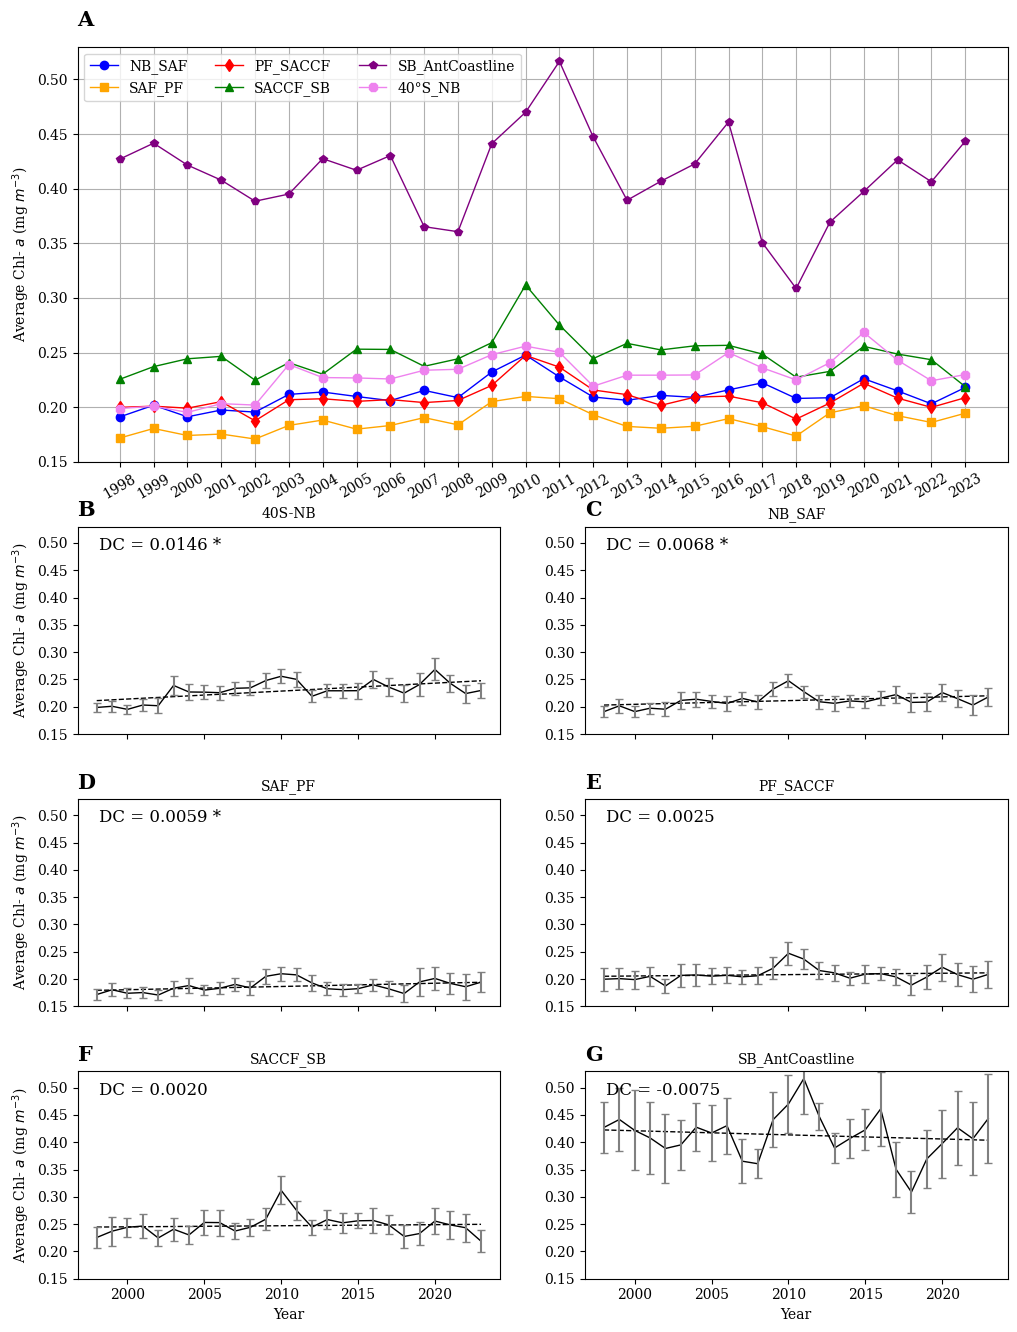

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.ticker import FuncFormatter
import pandas as pd
# df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
df = pd.read_csv('./fronts.csv')
def two_decimals(x, pos):
    return f'{x:.2f}'

# Assuming df is your DataFrame with Chlorophyll-a data
# Convert the 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract the year information from the date
df['year'] = df['time'].dt.year

# Calculate the yearly average Chlorophyll-a value
yearly_avg = df.groupby('year').mean()

# Calculate the standard error for each year and each region
def calculate_standard_error(group):
    return group.std() / np.sqrt(group.count())

# Apply the function to calculate standard error for each year
yearly_se = df.groupby('year').apply(calculate_standard_error)

# Set plot style with serif font
plt.rcParams['font.family'] = 'serif'

# Set the figure size and create subplots
fig = plt.figure(figsize=(12, 16))
gs = fig.add_gridspec(4, 2, hspace=0.25, wspace=0.2, height_ratios=[2, 1, 1, 1])  # Adjust hspace, wspace, and height_ratios

# Create subplots with shared y-axis
ax1 = fig.add_subplot(gs[0, :])  # All Austral alone on the top row
ax2 = fig.add_subplot(gs[1, 0], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 1], sharey=ax1)
ax4 = fig.add_subplot(gs[2, 0], sharey=ax1)
ax5 = fig.add_subplot(gs[2, 1], sharey=ax1)
ax6 = fig.add_subplot(gs[3, 0], sharey=ax1)
ax7 = fig.add_subplot(gs[3, 1], sharey=ax1)

# List of subplot variables for easy access
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]

# Set y-axis limits to 0.15 to 0.4 for all plots
for ax in axes:
    ax.set_ylim(0.15, 0.53)

# Update ax1 plot with Seaborn
ax1.plot(yearly_avg.index, yearly_avg['NB_SAF'], marker='o', color='blue', linestyle='-', label='NB_SAF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SAF_PF'], marker='s', linestyle='-', color='orange', label='SAF_PF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['PF_SACCF'], marker='d', linestyle='-', color='red', label='PF_SACCF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SACCF_SB'], marker='^', linestyle='-', color='green', label='SACCF_SB', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SB_AntCoastline'], marker='p', linestyle='-', color='purple', label='SB_AntCoastline', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['40S-NB'], marker='8', linestyle='-', color='violet', label='40°S_NB', linewidth=1)
ax1.legend(ncol=3, loc='upper left')
ax1.set_xticks(yearly_avg.index)
ax1.set_xticklabels(yearly_avg.index, rotation=30, fontsize=10)
ax1.grid()
ax1.set_ylabel('Average Chl- $a$ (mg $m^{-3}$)')
ax1.yaxis.set_major_formatter(FuncFormatter(two_decimals))
ax1.annotate('A', xy=(0, 1.05), xycoords='axes fraction', fontsize=15, weight='bold', color='k')

# Plotting individual regions and adding regression lines for other axes
regions = ['Southern Ocean', '40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']
for i, region in enumerate(regions[1:], start=1):  # Skip 'All Austral' for other subplots
#for i, region in enumerate(regions):
    x = yearly_avg.index
    y = yearly_avg[region]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    regression_line = intercept + slope * x  
    
    # Plot data points and regression line
    axes[i].plot(x, y, linestyle='-', color='black', label=region, linewidth=1)
    axes[i].plot(x, regression_line, color='black', linestyle='--', label='Regression Line', linewidth=1)
    
    # Calculate standard error for each year
    se_region = yearly_se[region]
    
    # Add error bars
    axes[i].errorbar(x, y, yerr=se_region, fmt='none', ecolor='gray', capsize=3)
    
    # Set labels, title, and legend
    axes[i].set_title(region, fontsize=10)
    # Only add y-axis labels to B, D, and F subplots
    if i % 2 == 1:  # This means B, D, F (i=1, 3, 5)
        axes[i].set_ylabel('Average Chl-$a$ (mg $m^{-3}$)')
    axes[i].yaxis.set_major_formatter(FuncFormatter(two_decimals))
    # Remove x-ticks for all except the last row
    if i < 5:
        axes[i].set_xticklabels([])
    # Calculate and add DC value and significance indicator to the plot
    DC_value = slope * 10
    significance_indicator = '*' if p_value < 0.05 else ''
    DC_text = f'DC = {DC_value:.4f} {significance_indicator}'
    axes[i].text(0.05, 0.95, DC_text, transform=axes[i].transAxes, fontsize=12, verticalalignment='top')

    # Mark each subplot with letters (a, b, c, d, ...)
    axes[i].annotate(chr(97 + i).upper(), xy=(0, 1.05), xycoords='axes fraction', fontsize=15, weight='bold', color='k')
    print(p_value)
axes[5].set_xlabel('Year')
axes[6].set_xlabel('Year')
# Adjust layout to prevent overlap

plt.tight_layout()
# Save or show the plot
#plt.savefig('subplots_with_regression_and_pvalues_fig_7.png', dpi=300)
plt.show()

## Create the main visualizations

These figures show spatial distributions and relationships between environmental variables. Interpret each output using its units, time window, colour scale, and missing-data pattern.

0.0010591841939467787
0.03683797504351598
0.03188466032859854
0.4566957706750868
0.6888930942975309
0.5065400530150461


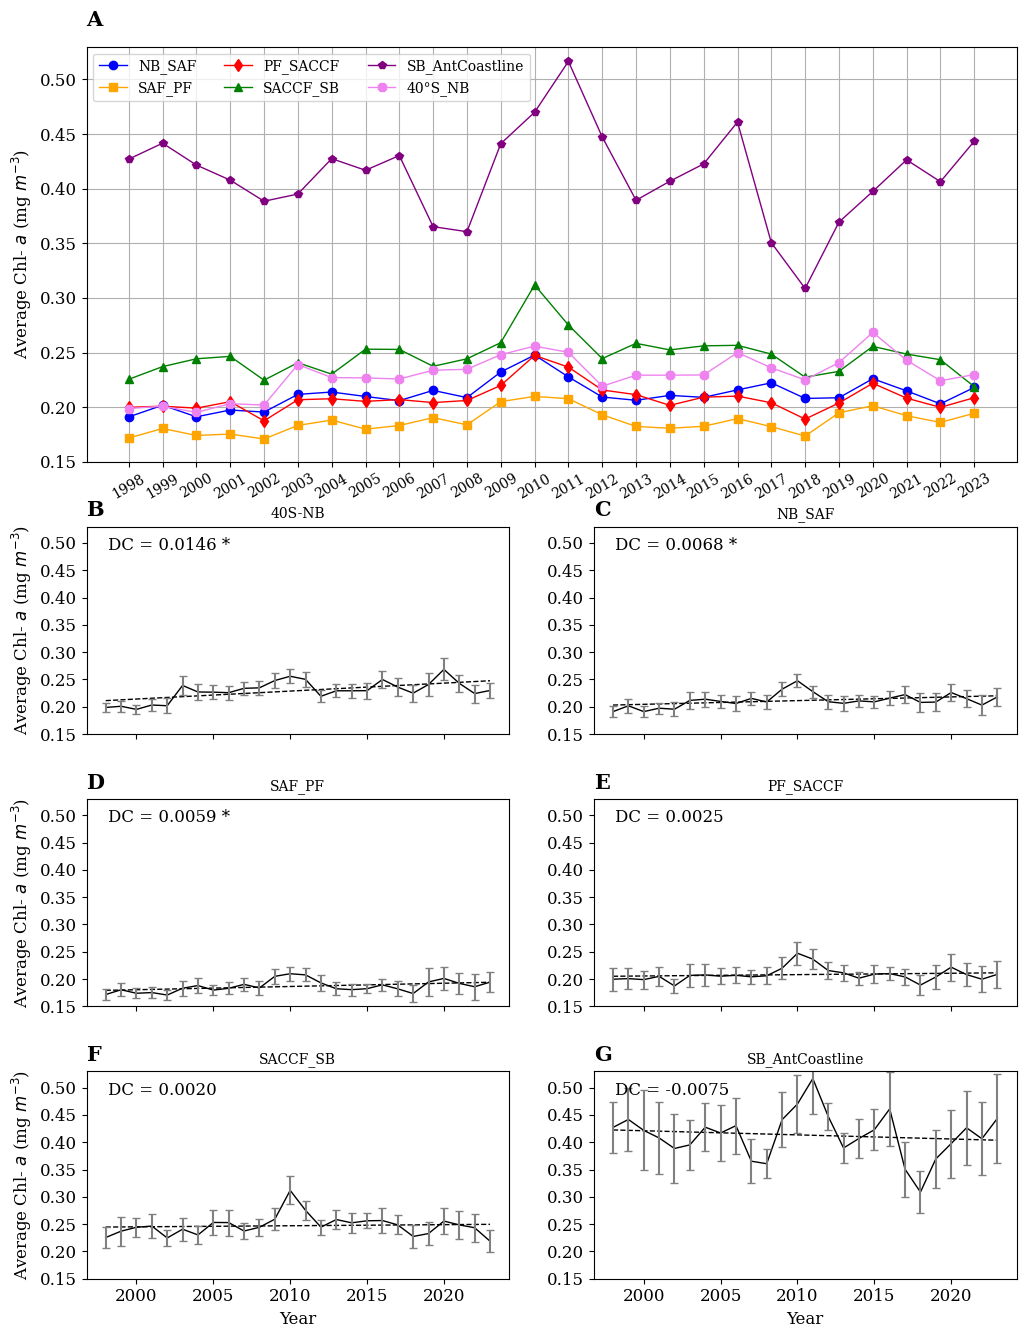

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from matplotlib.ticker import FuncFormatter
import pandas as pd
#df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
def two_decimals(x, pos):
    return f'{x:.2f}'

# Assuming df is your DataFrame with Chlorophyll-a data
# Convert the 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract the year information from the date
df['year'] = df['time'].dt.year

# Calculate the yearly average Chlorophyll-a value
yearly_avg = df.groupby('year').mean()

# Calculate the standard error for each year and each region
def calculate_standard_error(group):
    return group.std() / np.sqrt(group.count())

# Apply the function to calculate standard error for each year
yearly_se = df.groupby('year').apply(calculate_standard_error)

# Set plot style with serif font
plt.rcParams['font.family'] = 'serif'

# Set the figure size and create subplots
fig = plt.figure(figsize=(12, 16))
gs = fig.add_gridspec(4, 2, hspace=0.25, wspace=0.2, height_ratios=[2, 1, 1, 1])  # Adjust hspace, wspace, and height_ratios

# Create subplots with shared y-axis
ax1 = fig.add_subplot(gs[0, :])  # All Austral alone on the top row
ax2 = fig.add_subplot(gs[1, 0], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 1], sharey=ax1)
ax4 = fig.add_subplot(gs[2, 0], sharey=ax1)
ax5 = fig.add_subplot(gs[2, 1], sharey=ax1)
ax6 = fig.add_subplot(gs[3, 0], sharey=ax1)
ax7 = fig.add_subplot(gs[3, 1], sharey=ax1)

# List of subplot variables for easy access
axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]

# Set y-axis limits to 0.15 to 0.4 for all plots
for ax in axes:
    ax.set_ylim(0.15, 0.53)

# Update ax1 plot with Seaborn
ax1.plot(yearly_avg.index, yearly_avg['NB_SAF'], marker='o', color='blue', linestyle='-', label='NB_SAF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SAF_PF'], marker='s', linestyle='-', color='orange', label='SAF_PF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['PF_SACCF'], marker='d', linestyle='-', color='red', label='PF_SACCF', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SACCF_SB'], marker='^', linestyle='-', color='green', label='SACCF_SB', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['SB_AntCoastline'], marker='p', linestyle='-', color='purple', label='SB_AntCoastline', linewidth=1)
ax1.plot(yearly_avg.index, yearly_avg['40S-NB'], marker='8', linestyle='-', color='violet', label='40°S_NB', linewidth=1)
ax1.legend(ncol=3, loc='upper left',fontsize=10)
ax1.set_xticks(yearly_avg.index)
ax1.set_xticklabels(yearly_avg.index, rotation=30, fontsize=10)
ax1.grid()
ax1.set_ylabel('Average Chl- $a$ (mg $m^{-3}$)')
ax1.yaxis.set_major_formatter(FuncFormatter(two_decimals))
ax1.annotate('A', xy=(0, 1.05), xycoords='axes fraction', fontsize=15, weight='bold', color='k')

# Plotting individual regions and adding regression lines for other axes
regions = ['Southern Ocean', '40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']
for i, region in enumerate(regions[1:], start=1):  # Skip 'All Austral' for other subplots
#for i, region in enumerate(regions):
    x = yearly_avg.index
    y = yearly_avg[region]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    regression_line = intercept + slope * x  
    
    # Plot data points and regression line
    axes[i].plot(x, y, linestyle='-', color='black', label=region, linewidth=1)
    axes[i].plot(x, regression_line, color='black', linestyle='--', label='Regression Line', linewidth=1)
    
    # Calculate standard error for each year
    se_region = yearly_se[region]
    
    # Add error bars
    axes[i].errorbar(x, y, yerr=se_region, fmt='none', ecolor='gray', capsize=3)
    
    # Set labels, title, and legend
    axes[i].set_title(region, fontsize=10)
    # Only add y-axis labels to B, D, and F subplots
    if i % 2 == 1:  # This means B, D, F (i=1, 3, 5)
        axes[i].set_ylabel('Average Chl- $a$ (mg $m^{-3}$)')
    axes[i].yaxis.set_major_formatter(FuncFormatter(two_decimals))
    # Remove x-ticks for all except the last row
    if i < 5:
        axes[i].set_xticklabels([])
    # Calculate and add DC value and significance indicator to the plot
    DC_value = slope * 10
    significance_indicator = '*' if p_value < 0.05 else ''
    DC_text = f'DC = {DC_value:.4f} {significance_indicator}'
    axes[i].text(0.05, 0.95, DC_text, transform=axes[i].transAxes, fontsize=12, verticalalignment='top')

    # Mark each subplot with letters (a, b, c, d, ...)
    axes[i].annotate(chr(97 + i).upper(), xy=(0, 1.05), xycoords='axes fraction', fontsize=15, weight='bold', color='k')
    print(p_value)
axes[5].set_xlabel('Year')
axes[6].set_xlabel('Year')
# Adjust layout to prevent overlap

plt.tight_layout()
# Save or show the plot
#plt.savefig('subplots_with_regression_and_pvalues_fig_7.png', dpi=300)
plt.show()

In [11]:
df1 = df[["40S-NB","NB_SAF","SAF_PF","PF_SACCF","SACCF_SB","SB_AntCoastline", "Southern Ocean"]].agg(['min','max','mean', 'std', 'sem'])
#df1.to_csv('CHL-MEAN.CSV')
df1

,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean
min,0.150260,0.144051,0.131170,0.122716,0.143044,0.203242,0.138565
max,0.383170,0.355191,0.408885,0.431611,0.413385,0.703362,0.446361
mean,0.229403,0.211565,0.186737,0.208110,0.246843,0.411013,0.246691
std,0.050291,0.046810,0.049561,0.058444,0.061202,0.118675,0.075730
sem,0.002847,0.002650,0.002806,0.003493,0.003926,0.010489,0.004752


In [25]:
df1 = df[["40S-NB","NB_SAF","SAF_PF","PF_SACCF","SACCF_SB","SB_AntCoastline", "Southern Ocean"]].agg(['min','max','mean', 'std', 'sem'])
#df1.to_csv('CHL-MEAN.CSV')
df1

,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean
min,0.147234,0.144056,0.131170,0.122716,0.134682,0.136598,0.138566
max,0.374201,0.355219,0.408885,0.431612,0.413388,0.703360,0.446375
mean,0.222823,0.211571,0.186737,0.205129,0.235408,0.292909,0.232762
std,0.049267,0.046815,0.049561,0.056898,0.061422,0.129843,0.074708


In [26]:
import pandas as pd

df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
# Convert the 'Time' column to datetime
df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y')

# Define a function to group dates into seasons
def get_season(month):
    if month in [1, 2, 3]:
        return 'Summer'
    elif month in [4, 5, 6]:
        return 'Autumn'
    elif month in [7, 8, 9]:
        return 'Winter'
    elif month in [10, 11, 12]:
        return 'Spring'
    else:
        return 'Invalid Month'

# Extract the month from the 'Time' column and create a 'Season' column
df['Month'] = df['time'].dt.month
df['Season'] = df['Month'].apply(get_season)

# Group the data by 'Season' and calculate mean and standard deviation
seasonal_stats = df.groupby('Season').agg({
    '40S-NB': ['mean', 'std'],
    'NB_SAF': ['mean', 'std'],
    'SAF_PF': ['mean', 'std'],
    'PF_SACCF': ['mean', 'std'],
    'SACCF_SB': ['mean', 'std'],
    'SB_AntCoastline': ['mean', 'std'],
    'Southern Ocean': ['mean', 'std'],
})

# Rename the columns for clarity
seasonal_stats.columns = ['Mean_30S-NB', 'Std_30S-NB', 'Mean_NB_SAF', 'Std_NB_SAF', 'Mean_SAF_PF', 'Std_SAF_PF', 'Mean_PF_SACCF', 'Std_PF_SACCF', 'Mean_SACCF_SB', 'Std_SACCF_SB', 'Mean_SB_AntCoastline', 'Std_SB_AntCoastline', "Mean_All Austral", "Std_All Austral"]

# Display the seasonal statistics
print(seasonal_stats)

        Mean_30S-NB  Std_30S-NB  Mean_NB_SAF  Std_NB_SAF  Mean_SAF_PF  \
Season                                                                  
Autumn     0.187269    0.019912     0.181730    0.018377     0.158457   
Spring     0.278528    0.033019     0.261792    0.035892     0.247762   
Summer     0.244077    0.034159     0.235794    0.029554     0.181715   
Winter     0.181418    0.023059     0.166968    0.016914     0.159014   

        Std_SAF_PF  Mean_PF_SACCF  Std_PF_SACCF  Mean_SACCF_SB  Std_SACCF_SB  \
Season                                                                         
Autumn    0.015690       0.167335      0.024988       0.193569      0.040710   
Spring    0.058812       0.271487      0.058577       0.286523      0.051819   
Summer    0.026144       0.211403      0.039888       0.272953      0.047821   
Winter    0.012074       0.170292      0.015875       0.188586      0.023230   

        Mean_SB_AntCoastline  Std_SB_AntCoastline  Mean_All Austral  \
Season   

In [3]:
import pandas as pd
import numpy as np

# Load the data
#df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')

# Convert the 'Time' column to datetime
df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y')

# Define a function to group dates into seasons
def get_season(month):
    if month in [1, 2, 3]:
        return 'Summer'
    elif month in [4, 5, 6]:
        return 'Autumn'
    elif month in [7, 8, 9]:
        return 'Winter'
    elif month in [10, 11, 12]:
        return 'Spring'
    else:
        return 'Invalid Month'

# Extract the month from the 'time' column and create a 'Season' column
df['Month'] = df['time'].dt.month
df['Season'] = df['Month'].apply(get_season)

# Group the data by 'Season' and calculate mean and standard error
seasonal_stats = df.groupby('Season').agg(['mean', 'std', 'count'])

# Calculate the standard error (SE)
for col in ['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean']:
    seasonal_stats[(col, 'SE')] = seasonal_stats[(col, 'std')] / np.sqrt(seasonal_stats[(col, 'count')])

# Keep only mean and SE in the results
seasonal_stats = seasonal_stats.loc[:, [(col, stat) for col in ['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean'] for stat in ['mean', 'SE']]]

# Rename the columns for clarity
seasonal_stats.columns = [f"{stat}_{col}" for col, stat in seasonal_stats.columns]

# Display the seasonal statistics
print(seasonal_stats)

        mean_40S-NB  SE_40S-NB  mean_NB_SAF  SE_NB_SAF  mean_SAF_PF  \
Season                                                                
Autumn     0.193496   0.002440     0.181729   0.002081     0.158457   
Spring     0.285382   0.003805     0.261775   0.004064     0.247762   
Summer     0.251811   0.003964     0.235791   0.003346     0.181715   
Winter     0.186924   0.002724     0.166964   0.001915     0.159014   

        SE_SAF_PF  mean_PF_SACCF  SE_PF_SACCF  mean_SACCF_SB  SE_SACCF_SB  \
Season                                                                      
Autumn   0.001777       0.161303     0.002459       0.191515     0.004784   
Spring   0.006659       0.271486     0.006633       0.286525     0.005868   
Summer   0.002960       0.211403     0.004516       0.272949     0.005415   
Winter   0.001367       0.169806     0.001747       0.185401     0.002524   

        mean_SB_AntCoastline  SE_SB_AntCoastline  mean_Southern Ocean  \
Season                               

In [4]:
import pandas as pd
import numpy as np

# Load the data
# df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')

# Convert the 'Time' column to datetime
df['time'] = pd.to_datetime(df['time'], format='%d/%m/%Y')

# Define a function to group dates into seasons
def get_season(month):
    if month in [1, 2, 3]:
        return 'Summer'
    elif month in [4, 5, 6]:
        return 'Autumn'
    elif month in [7, 8, 9]:
        return 'Winter'
    elif month in [10, 11, 12]:
        return 'Spring'
    else:
        return 'Invalid Month'

# Extract the month from the 'time' column and create a 'Season' column
df['Month'] = df['time'].dt.month
df['Season'] = df['Month'].apply(get_season)

# Define the target columns
target_cols = ['40S-NB', 'NB_SAF', 'SAF_PF', 'PF_SACCF', 'SACCF_SB', 'SB_AntCoastline', 'Southern Ocean']

# Group the data by 'Season' and calculate mean, std, and count
seasonal_stats = df.groupby('Season')[target_cols].agg(['mean', 'std', 'count'])

# Calculate SE and add 'n' (sample size) to output
for col in target_cols:
    seasonal_stats[(col, 'SE')] = seasonal_stats[(col, 'std')] / np.sqrt(seasonal_stats[(col, 'count')])
    seasonal_stats[(col, 'n')] = seasonal_stats[(col, 'count')]

# Keep only mean, SE, and n in the results
seasonal_stats = seasonal_stats.loc[:, [(col, stat) for col in target_cols for stat in ['mean', 'SE', 'n']]]

# Rename the columns for clarity
seasonal_stats.columns = [f"{stat}_{col}" for col, stat in seasonal_stats.columns]

# Display the seasonal statistics
print(seasonal_stats)

        mean_40S-NB  SE_40S-NB  n_40S-NB  mean_NB_SAF  SE_NB_SAF  n_NB_SAF  \
Season                                                                       
Autumn     0.193496   0.002440        78     0.181729   0.002081        78   
Spring     0.285382   0.003805        78     0.261775   0.004064        78   
Summer     0.251811   0.003964        78     0.235791   0.003346        78   
Winter     0.186924   0.002724        78     0.166964   0.001915        78   

        mean_SAF_PF  SE_SAF_PF  n_SAF_PF  mean_PF_SACCF  ...  n_PF_SACCF  \
Season                                                   ...               
Autumn     0.158457   0.001777        78       0.161303  ...          53   
Spring     0.247762   0.006659        78       0.271486  ...          78   
Summer     0.181715   0.002960        78       0.211403  ...          78   
Winter     0.159014   0.001367        78       0.169806  ...          71   

        mean_SACCF_SB  SE_SACCF_SB  n_SACCF_SB  mean_SB_AntCoastline  \
Se

In [28]:
seasonal_stats.to_csv("/so_data/Revised_data/mean_se.csv")

In [30]:
import pandas as pd
df = pd.read_csv('/so_data/Revised_data/file_L3_2023_nb.csv')
# Convert the date column to a datetime format (assuming it's already in datetime format)
df['time'] = pd.to_datetime(df['time'])

# Extract the year information from the date
df['year'] = df['time'].dt.year

# Calculate the yearly average Chlorophyll-a value
yearly_avg = df.groupby('year').mean()
yearly_avg

,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean
year,,,,,,,
1998,0.194513,0.191040,0.171704,0.190773,0.206059,0.276036,0.213140
1999,0.196223,0.201737,0.180434,0.196529,0.215683,0.276024,0.220812
2000,0.190666,0.191125,0.174018,0.196950,0.230030,0.297693,0.224488
2001,0.198790,0.197341,0.175326,0.200967,0.234187,0.295024,0.224422
2002,0.197043,0.195447,0.170773,0.185730,0.222261,0.280613,0.216135
2003,0.232318,0.211638,0.183246,0.201974,0.228384,0.285755,0.229087
2004,0.220703,0.213823,0.188148,0.202660,0.222034,0.302131,0.235467
2005,0.220115,0.209735,0.179819,0.205250,0.245707,0.299219,0.235079
2006,0.219370,0.205934,0.183144,0.205058,0.242853,0.300720,0.236722


In [32]:
yearly_avg.to_csv("yearly_data.csv")

In [28]:
chl_T= xr.open_dataset("/so_data/Revised_data/CHL_Trend_1998_2023.nc")
Chl_sig= xr.open_dataset('/so_data/Revised_data/p_value_L3_CHL.nc')

In [4]:
%run antarctic_map.py

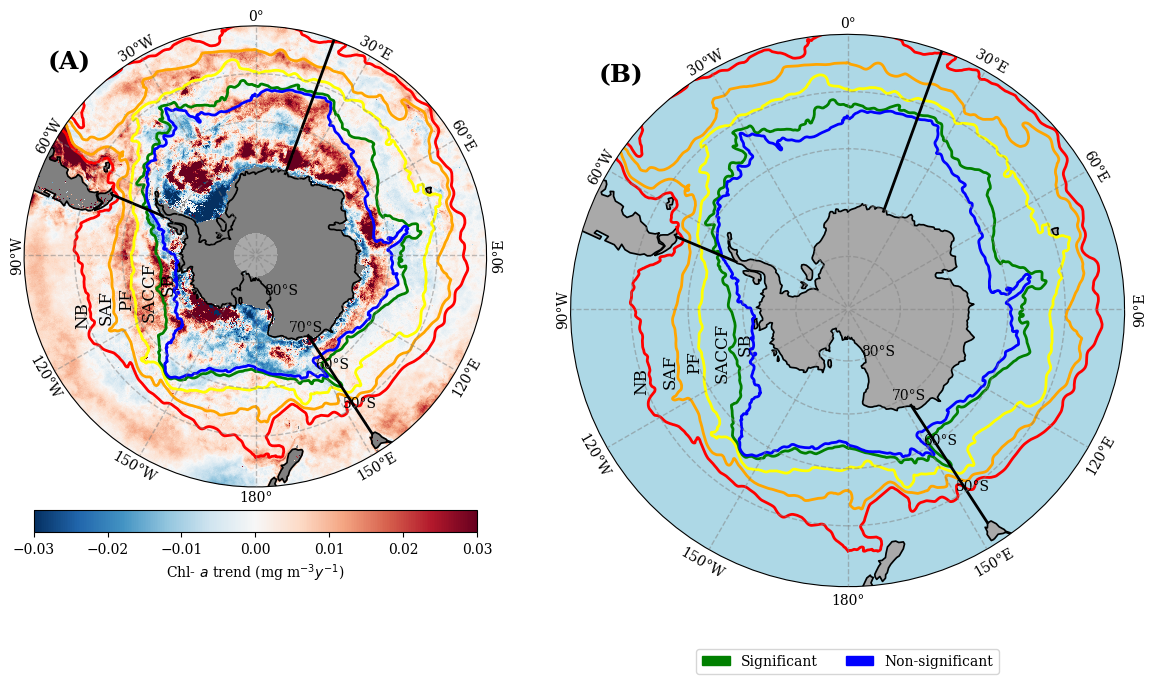

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
plt.figure(figsize=(12, 6.5))

# Create the first subplot
plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
ax1 = plt.gca()
ax1 = antarctic_map(ax1)
colormap = plt.cm.get_cmap('RdBu_r').copy()
colormap.set_bad(color='gray')
im1 = ax1.pcolormesh(chl_T.lon, chl_T.lat, chl_T.trend.values, cmap=colormap,vmin=-0.03, vmax=0.03, transform=ccrs.PlateCarree())
# Customize colorbar ticks and labels as needed
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8, pad=0.04, orientation='horizontal')
cbar1.ax.set_xlabel('Chl- ${a}$ trend (mg m$^{-3}y^{-1}$)')
ax1.text(0.05, 0.95, '(A)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the second subplot
# plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
# ax2 = plt.gca()
# ax2 = antarctic_map(ax2)
# # olive_green = (0.5, 0.5, 0) # RGB values range from 0 to 1
# # bright_pink = (1, 0.08, 0.58)
# colors = ['green', 'blue']
# #colors = [olive_green, bright_pink]
# # Create a custom colormap using ListedColormap
# cmap = mcolors.ListedColormap(colors)
# # Create a custom normalization for the colormap
# norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)
# im2 = ax2.pcolormesh(Chl_sig.longitude, Chl_sig.latitude, Chl_sig["__xarray_dataarray_variable__"].values, cmap=cmap, norm=norm,transform=ccrs.PlateCarree())
# cbar2 = plt.colorbar(im2, ax=ax2, shrink=1, pad=0.03, orientation='horizontal')
# cbar2.ax.set_xlabel('')
# ax2.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')
# plt.tight_layout()
import matplotlib.patches as mpatches

plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
ax2 = plt.gca()
ax2 = antarctic_map(ax2)

colors = ['green', 'blue']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)

#im2 = ax2.pcolormesh(Chl_sig.longitude, Chl_sig.latitude, Chl_sig["__xarray_dataarray_variable__"].values, cmap=cmap, norm=norm,transform=ccrs.PlateCarree())
# Create patches for the legend
patches = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, ["Significant", "Non-significant"])]

# Add the legend below the map
plt.legend(handles=patches, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)  # Adjust bbox_to_anchor to position it below

# Add subplot label
ax2.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')
plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_3.jpg', dpi=600)

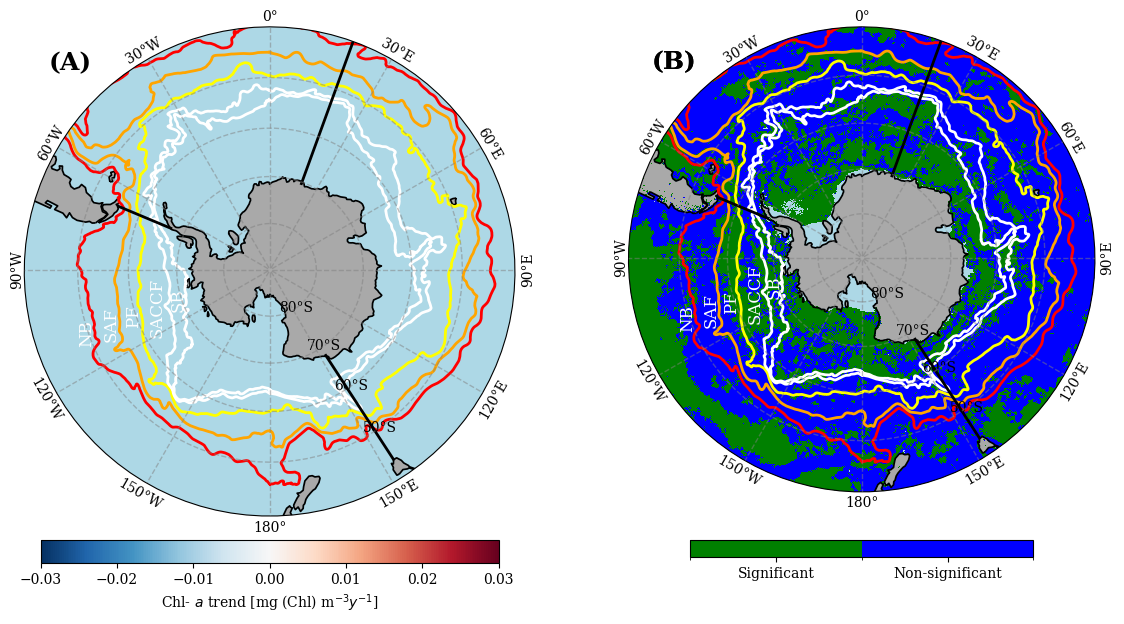

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
plt.figure(figsize=(12, 6.5))

# Create the first subplot
plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
ax1 = plt.gca()
ax1 = antarctic_map(ax1)
colormap = plt.cm.get_cmap('RdBu_r').copy()
colormap.set_bad(color='gray')
#im1 = ax1.pcolormesh(chl_T.lon, chl_T.lat, chl_T.trend.values, cmap=colormap, vmin=-0.03, vmax=0.03, transform=ccrs.PlateCarree())
# Customize colorbar ticks and labels as needed

# Adjust colorbar shrink parameter for better alignment
cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8, pad=0.04, orientation='horizontal')  # Adjust shrink and pad
cbar1.ax.set_xlabel('Chl- ${a}$ trend [mg (Chl) m$^{-3}y^{-1}$]')
ax1.text(0.05, 0.95, '(A)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the second subplot
plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
ax2 = plt.gca()
ax2 = antarctic_map(ax2)

colors = ['green', 'blue']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm([0, 0.05, 1], cmap.N)

im2 = ax2.pcolormesh(Chl_sig.longitude, Chl_sig.latitude, Chl_sig["__xarray_dataarray_variable__"].values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

# Create patches for the legend
cbar2 = plt.colorbar(
    mappable=plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    ax=ax2, orientation='horizontal', shrink=0.6, pad=0.08
)

# Set colorbar ticks and labels
cbar2.set_ticks([0.025, 0.525])  # Midpoints for "Significant" and "Non-significant"
cbar2.set_ticklabels(["Significant", "Non-significant"])

# Add subplot label
ax2.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')


# Add subplot label
ax2.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')

# Ensure both plots have equal spacing
plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_3.jpg', dpi=600)
plt.show()

In [7]:
Chl_sig

<xarray.Dataset>
Dimensions:                        (latitude: 1321, longitude: 8640)
Coordinates:
    degree                         int64 ...
  * latitude                       (latitude) float32 -29.98 -30.02 ... -84.98
  * longitude                      (longitude) float32 -180.0 -179.9 ... 180.0
Data variables:
    __xarray_dataarray_variable__  (latitude, longitude) float64 ...

In [5]:
sst_T= xr.open_dataset('/so_data/Revised_data/SST_Trend_1998_2023.nc')
MLD_T= xr.open_dataset('/so_data/Revised_data/MLD_Trend_1998_2023.nc')
wind_T= xr.open_dataset('/so_data/Revised_data/ws_Trend_1998_2023.nc')
PAR_T= xr.open_dataset('/so_data/Revised_data/PAR_Trend_1998_2023.nc')

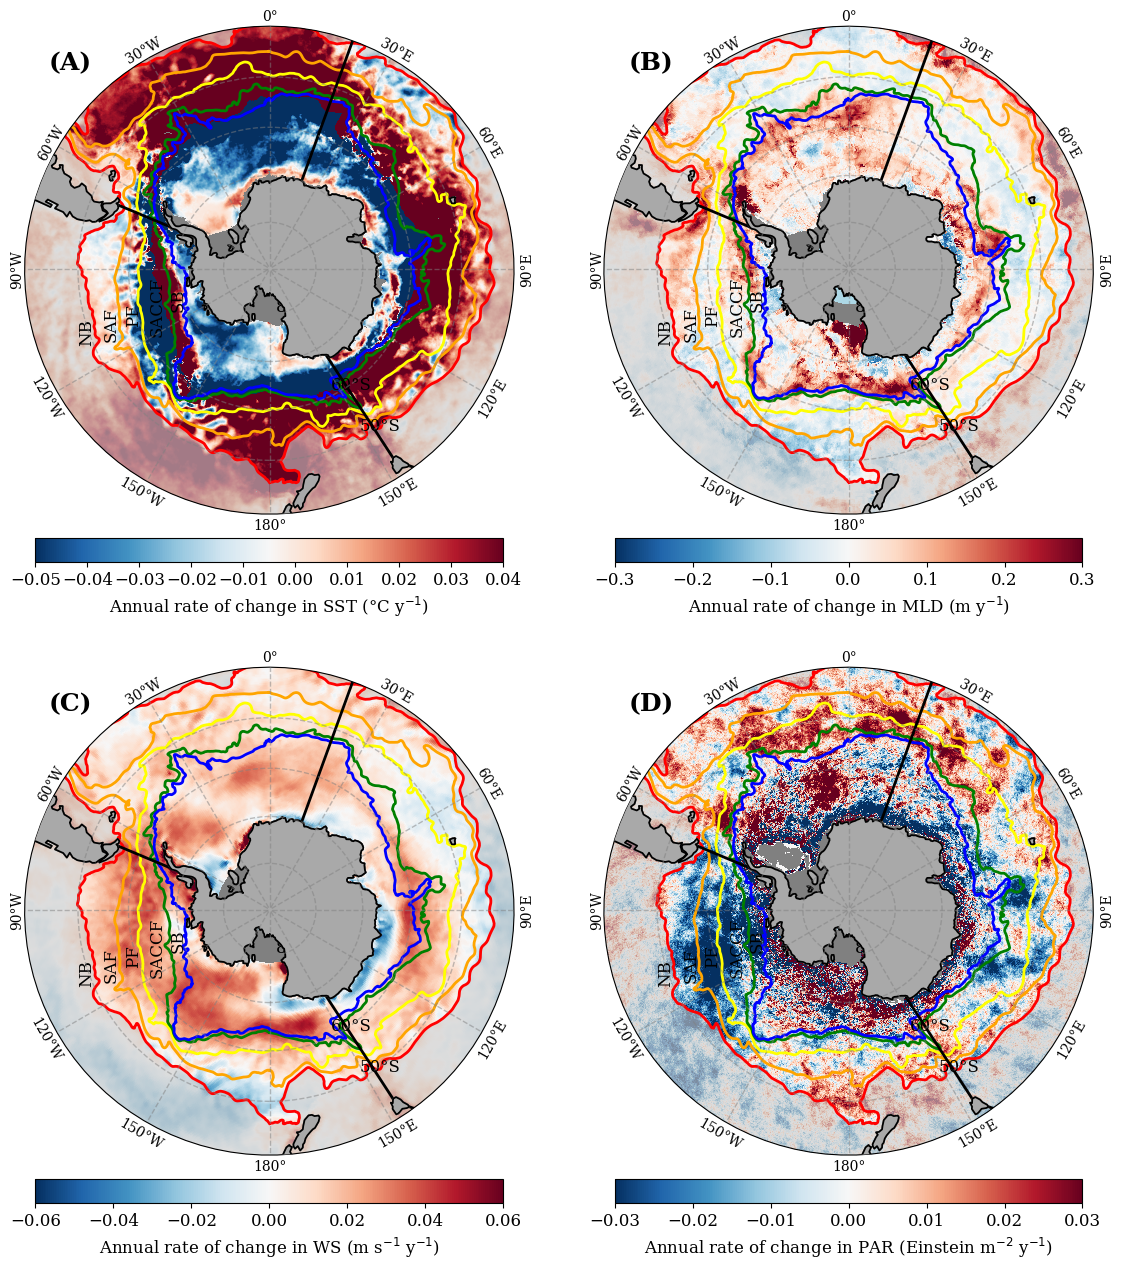

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import geopandas as gpd
shapefile_path = '/so_data/shapefile/30_nb/final_nb_30S.shp'
so_shape = gpd.read_file(shapefile_path)

# Create a union of the geometry for the mask
north_mask = so_shape.geometry.unary_union

# Define a function to apply the mask to a given axis
def apply_shapefile_mask(ax):
    # Plot the shapefile boundary
    so_shape.boundary.plot(ax=ax, color='black', linewidth=1)

    # Dim the area outside the boundary
    ax.add_geometries([north_mask], crs=ccrs.PlateCarree(), facecolor=(0.8, 0.8, 0.8, 0.6), edgecolor='none')  # Light Gray
    ax.set_aspect('equal', 'box')
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12
# Set the figure size to 15x18 inches
plt.figure(figsize=(12, 13))
# Create the third subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 1, projection=ccrs.SouthPolarStereo())
ax3 = plt.gca()
ax3 = antarctic_map(ax3)
colormap = plt.cm.get_cmap('RdBu_r').copy()
colormap.set_bad(color='gray')
ax3.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax3.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=10)
im3 = ax3.pcolormesh(sst_T.lon, sst_T.lat, sst_T.sst_trend.values*12, cmap=colormap,vmin=-0.05, vmax=0.04, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax3)  # Apply the mask
#im3 = ax3.pcolormesh(sst_T.lon, sst_T.lat, sst_T.trend_sst.values, cmap=colormap, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im3, ax=ax3, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Annual rate of change in SST (°C y$^{-1}$)')
plt.text(0.05, 0.95, '(A)', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the fourth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 2, projection=ccrs.SouthPolarStereo())
ax4 = plt.gca()
ax4 = antarctic_map(ax4)
ax4.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax4.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=10)
im4 = ax4.pcolormesh(MLD_T.longitude, MLD_T.latitude, MLD_T.mld_trend.values*12, cmap=colormap,vmin=-0.3, vmax=0.3, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax4)  # Apply the mask
cbar = plt.colorbar(im4, ax=ax4, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Annual rate of change in MLD (m y$^{-1}$)')
plt.text(0.05, 0.95, '(B)', transform=ax4.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the fifth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 3, projection=ccrs.SouthPolarStereo())
ax5 = plt.gca()
ax5 = antarctic_map(ax5)
ax5.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax5.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=10)
im5 = ax5.pcolormesh(wind_T.longitude, wind_T.latitude, wind_T.ws_trend.values*12, vmin=-0.06, vmax=0.06, cmap=colormap, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax5)  # Apply the mask
cbar = plt.colorbar(im5, ax=ax5, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Annual rate of change in WS (m s$^{-1}$ y$^{-1}$)')
plt.text(0.05, 0.95, '(C)', transform=ax5.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the sixth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 4, projection=ccrs.SouthPolarStereo())
ax6 = plt.gca()
ax6 = antarctic_map(ax6)
ax6.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
ax6.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=10)
im6 = ax6.pcolormesh(PAR_T.lon, PAR_T.lat, PAR_T.mld_trend.values*12, cmap=colormap,vmin=-0.03, vmax=0.03, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax6)  # Apply the mask
cbar = plt.colorbar(im6, ax=ax6, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Annual rate of change in PAR (Einstein m$^{-2}$ y$^{-1}$)')
plt.text(0.05, 0.95, '(D)', transform=ax6.transAxes, fontsize=18, fontweight='bold', va='top')
# Define legend lines and labels
# l_stf = Line2D([0], [0], color='red')
# l_saf = Line2D([0], [0], color='orange')
# l_pf = Line2D([0], [0], color='yellow')
# l_saccf = Line2D([0], [0], color='green')
# l_sbdy = Line2D([0], [0], color='blue')
# labels = ['NB (Northern Boundary)', 'SAF (Subantarctic Front)', 
#           'PF (Polar Front)', 'SACCF (Southern ACC Front)', 'SB (Southern Boundary)']

# # Add legend with adjusted position
# plt.legend(
#     [l_stf, l_saf, l_pf, l_saccf, l_sbdy], 
#     labels, 
#     ncol=3, frameon=True,
#     loc=10,  bbox_to_anchor=(-0.5, -0.5, 0.0, 0.0),
# )
plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_8.jpg', dpi=600)

In [15]:
PAR_T

<xarray.Dataset>
Dimensions:    (lat: 1320, lon: 8640)
Coordinates:
  * lat        (lat) float64 -30.02 -30.06 -30.1 -30.15 ... -84.9 -84.94 -84.98
  * lon        (lon) float64 -180.0 -179.9 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    mld_trend  (lat, lon) float64 -0.0002892 -0.0005691 -0.0008271 ... nan nan

In [30]:
change_SST=xr.open_dataset('/so_data/Revised_data/chnage_sst_chl.nc')
change_MLD=xr.open_dataset('/so_data/Revised_data/chnage_mld_chl.nc')
change_wind=xr.open_dataset('/so_data/Revised_data/chnage_wind_chl.nc')
change_PAR=xr.open_dataset('/so_data/Revised_data/chnage_MOD_PAR_chl.nc')

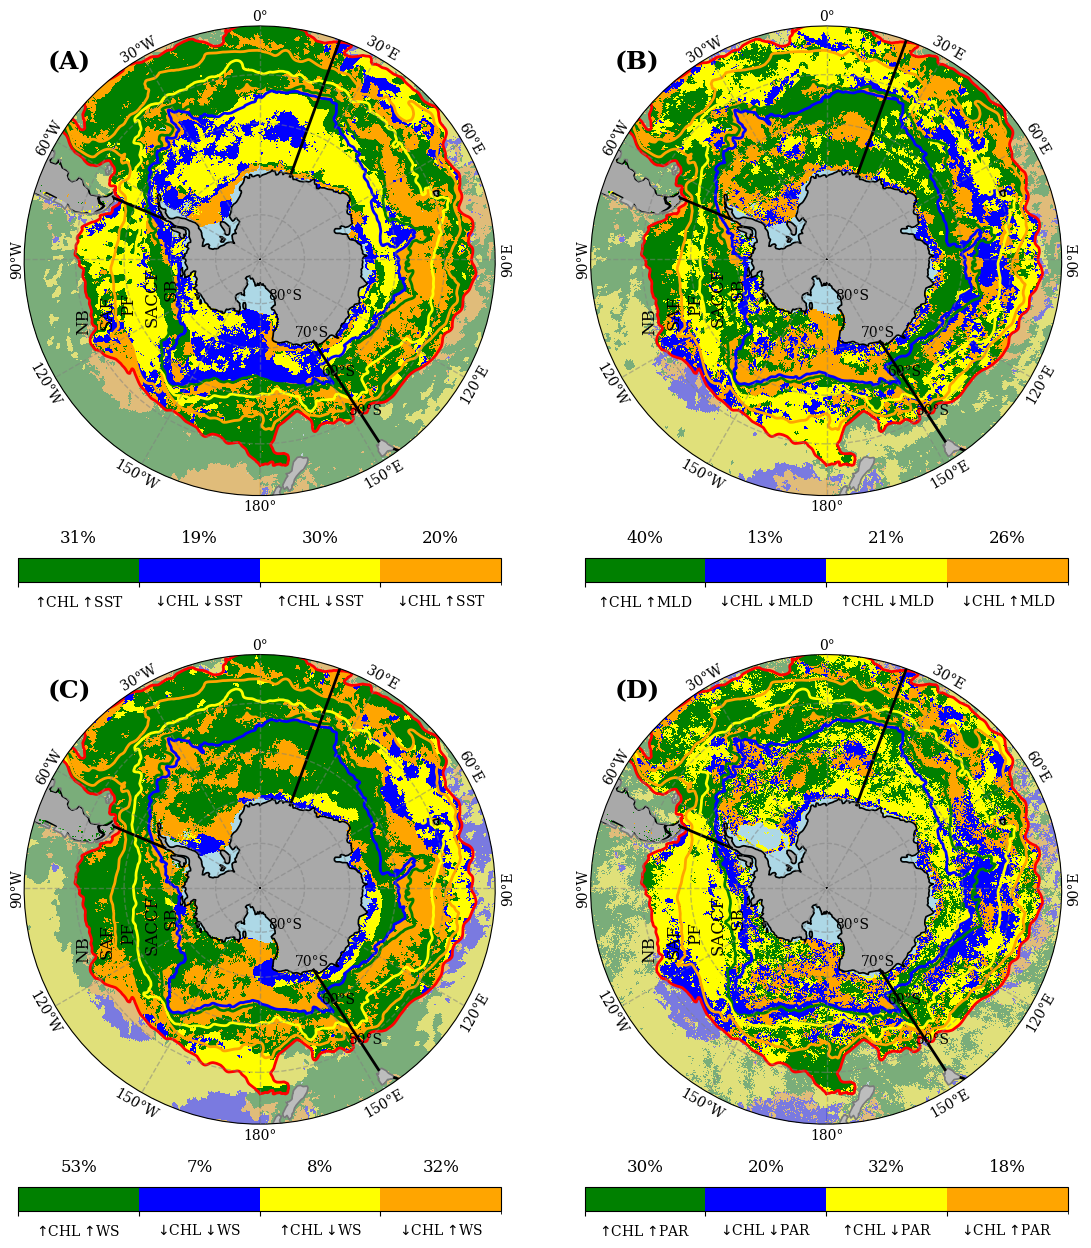

In [32]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 10
# Set the figure size to 15x18 inches
plt.figure(figsize=(12, 13))

plt.subplot(2, 2, 1, projection=ccrs.SouthPolarStereo())
ax1 = plt.gca()
ax1 = antarctic_map(ax1)
colors = ['green', 'blue', 'yellow', 'orange']
# Create a custom colormap using ListedColormap
cmap = mcolors.ListedColormap(colors)
# Create a custom normalization for the colormap
norm = mcolors.BoundaryNorm([-2, -1, 0, 1, 2], cmap.N)
im1 = ax1.pcolormesh(change_SST.lon, change_SST.lat, change_SST.trend.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax1)
# Customize colorbar ticks and labels as needed
cbar = plt.colorbar(im1, ax=ax1, shrink=0.8, pad=0.1, orientation='horizontal')
cbar.set_ticks([-2, -1, 0, 1])
cbar.set_ticklabels([])
for tick, label in zip(cbar.get_ticks()+0.5, ['$\u2191$CHL $\u2191$SST', '$\u2193$CHL $\u2193$SST', '$\u2191$CHL $\u2193$SST', '$\u2193$CHL $\u2191$SST']):
    cbar.ax.text(tick, -0.5, label, ha='center', va='top', fontsize= 10)
for pos, label in zip(cbar.get_ticks()+0.5, ['31%', '19%', '30%', '20%']):
    cbar.ax.text(pos, 1.5, label, ha='center', va='bottom', fontsize=12)
plt.text(0.05, 0.95, '(A)', transform=ax1.transAxes, fontsize=18, fontweight='bold', va='top')

#...........................................................
plt.subplot(2, 2, 2, projection=ccrs.SouthPolarStereo())
ax2 = plt.gca()
ax2 = antarctic_map(ax2)
colors = ['green', 'blue', 'yellow', 'orange']
# Create a custom colormap using ListedColormap
cmap = mcolors.ListedColormap(colors)
# Create a custom normalization for the colormap
norm = mcolors.BoundaryNorm([-2, -1, 0, 1, 2], cmap.N)
im2 = ax2.pcolormesh(change_MLD.lon, change_MLD.lat, change_MLD.trend.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax2)
# Customize colorbar ticks and labels as needed
cbar = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.1, orientation='horizontal')
cbar.set_ticks([-2, -1, 0, 1])
cbar.set_ticklabels([])
for tick, label in zip(cbar.get_ticks()+0.5, ['$\u2191$CHL $\u2191$MLD', '$\u2193$CHL $\u2193$MLD', '$\u2191$CHL $\u2193$MLD', '$\u2193$CHL $\u2191$MLD']):
    cbar.ax.text(tick, -0.5, label, ha='center', va='top', fontsize= 10)
for pos, label in zip(cbar.get_ticks()+0.5, ['40%', '13%', '21%', '26%']):
    cbar.ax.text(pos, 1.5, label, ha='center', va='bottom', fontsize=12)
plt.text(0.05, 0.95, '(B)', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top')

#...................................................................................................
plt.subplot(2,2,3, projection=ccrs.SouthPolarStereo())
ax3 = plt.gca()
ax3 = antarctic_map(ax3)
colors = ['green', 'blue', 'yellow', 'orange']
# Create a custom colormap using ListedColormap
cmap = mcolors.ListedColormap(colors)
# Create a custom normalization for the colormap
norm = mcolors.BoundaryNorm([-2, -1, 0, 1, 2], cmap.N)
im3 = ax3.pcolormesh(change_wind.lon, change_wind.lat, change_wind.trend.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax3)
# Customize colorbar ticks and labels as needed
cbar = plt.colorbar(im3, ax=ax3, shrink=0.8, pad=0.1, orientation='horizontal')
cbar.set_ticks([-2, -1, 0, 1])
cbar.set_ticklabels([])
for tick, label in zip(cbar.get_ticks()+0.5, ['$\u2191$CHL $\u2191$WS', '$\u2193$CHL $\u2193$WS', '$\u2191$CHL $\u2193$WS', '$\u2193$CHL $\u2191$WS']):
    cbar.ax.text(tick, -0.5, label, ha='center', va='top', fontsize= 10)
for pos, label in zip(cbar.get_ticks()+0.5, ['53%', '7%', '8%', '32%']):
    cbar.ax.text(pos, 1.5, label, ha='center', va='bottom', fontsize=12)
plt.text(0.05, 0.95, '(C)', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top')
#.............................................................................................

plt.subplot(2, 2, 4, projection=ccrs.SouthPolarStereo())
ax4 = plt.gca()
ax4= antarctic_map(ax4)
colors = ['green', 'blue', 'yellow', 'orange']
# Create a custom colormap using ListedColormap
cmap = mcolors.ListedColormap(colors)
# Create a custom normalization for the colormap
norm = mcolors.BoundaryNorm([-2, -1, 0, 1, 2], cmap.N)
im4= ax4.pcolormesh(change_PAR.lon, change_PAR.lat, change_PAR.trend.values, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax4)
# Customize colorbar ticks and labels as needed
cbar = plt.colorbar(im4, ax=ax4, shrink=0.8, pad=0.1, orientation='horizontal')
cbar.set_ticks([-2, -1, 0, 1])
cbar.set_ticklabels([])
for tick, label in zip(cbar.get_ticks()+0.5, ['$\u2191$CHL $\u2191$PAR', '$\u2193$CHL $\u2193$PAR', '$\u2191$CHL $\u2193$PAR', '$\u2193$CHL $\u2191$PAR']):
    cbar.ax.text(tick, -0.5, label, ha='center', va='top', fontsize= 10)
for pos, label in zip(cbar.get_ticks()+0.5, ['30%', '20%', '32%', '18%']):
    cbar.ax.text(pos, 1.5, label, ha='center', va='bottom', fontsize=12)
plt.text(0.05, 0.95, '(D)', transform=ax4.transAxes, fontsize=18, fontweight='bold', va='top')

plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_9.jpg', dpi=600)

In [7]:
sst_T= xr.open_dataset('/so_data/Revised_data//reg_anomalies_sst_chl.nc')
MLD_T= xr.open_dataset('/so_data/Revised_data//reg_anomalies_mld_chl.nc')
wind_T= xr.open_dataset('/so_data/Revised_data//reg_anomalies_ws_chl.nc')
PAR_T= xr.open_dataset('/so_data/Revised_data//reg_anoamlies_par_chl.nc')

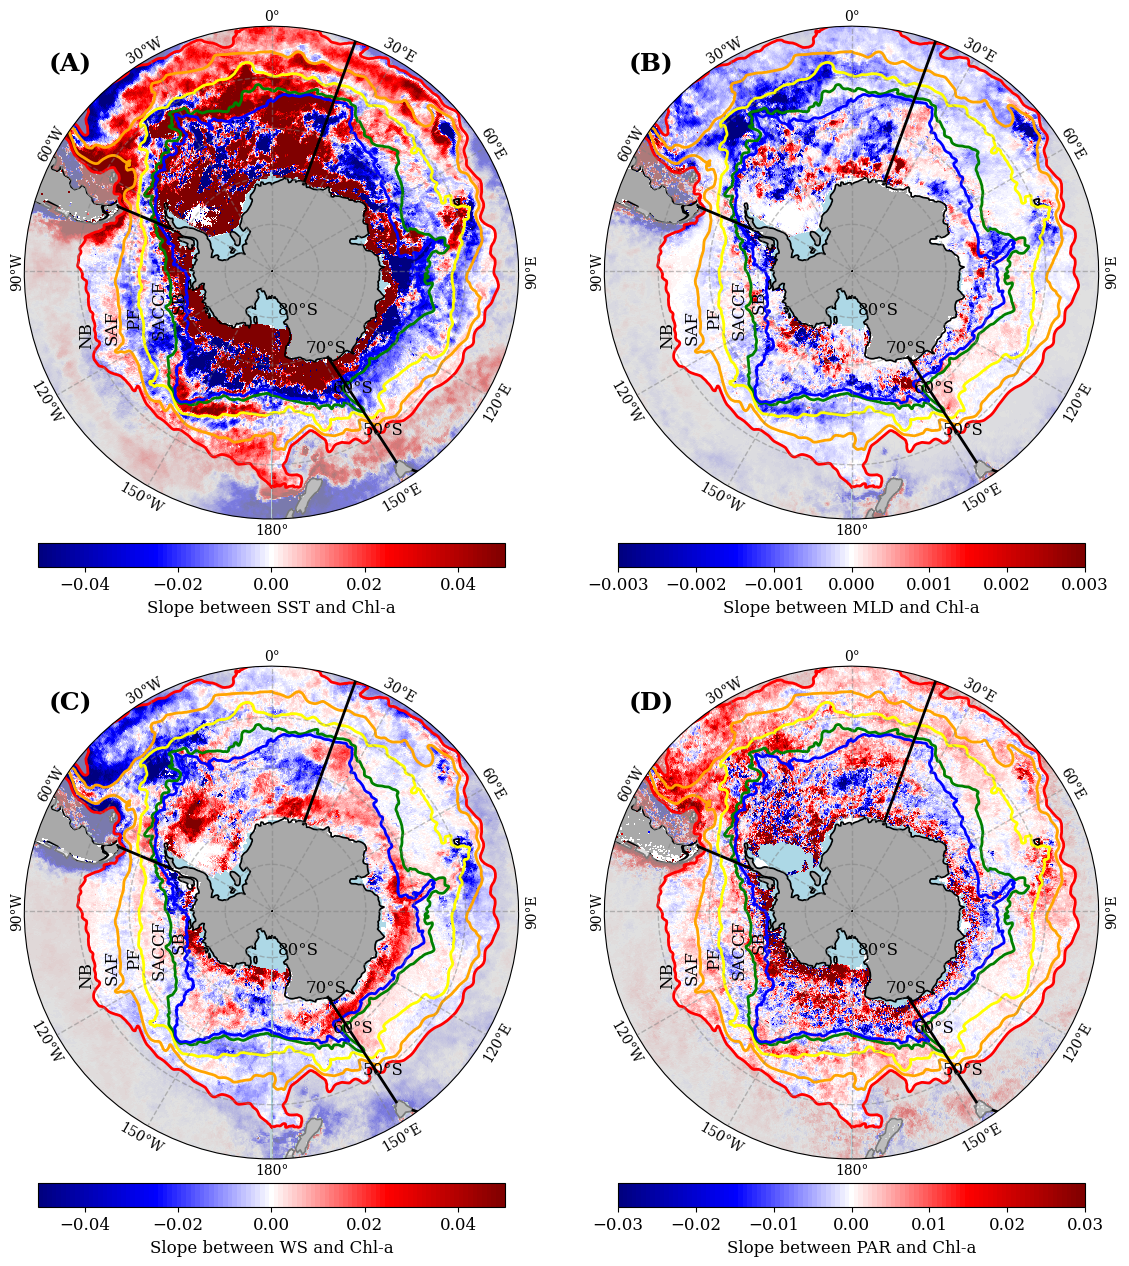

In [8]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12
import cmaps
# Set the figure size to 15x18 inches
plt.figure(figsize=(12, 13))
# Create the third subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 1, projection=ccrs.SouthPolarStereo())
ax3 = plt.gca()
ax3 = antarctic_map(ax3)
# colormap = plt.cm.get_cmap('RdBu_r').copy()
# colormap.set_bad(color='gray')
im3 = ax3.pcolormesh(sst_T.lon, sst_T.lat, sst_T.slope.values, cmap=cmaps.BlWhRe, vmin= -0.05, vmax=0.05, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax3)  # Apply the mask
cbar = plt.colorbar(im3, ax=ax3, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Slope between SST and Chl-a')
plt.text(0.05, 0.95, '(A)', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the fourth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 2, projection=ccrs.SouthPolarStereo())
ax4 = plt.gca()
ax4 = antarctic_map(ax4)
im4 = ax4.pcolormesh(MLD_T.lon, MLD_T.lat, MLD_T.slope.values, cmap=cmaps.BlWhRe, vmin= -0.003, vmax=0.003, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax4)  # Apply the mask
cbar = plt.colorbar(im4, ax=ax4, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Slope between MLD and Chl-a')
plt.text(0.05, 0.95, '(B)', transform=ax4.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the fifth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 3, projection=ccrs.SouthPolarStereo())
ax5 = plt.gca()
ax5 = antarctic_map(ax5)
# ax5.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
# ax5.add_feature(cfeature.COASTLINE, linewidth=1.25, zorder=10)
im5 = ax5.pcolormesh(wind_T.lon, wind_T.lat, wind_T.slope.values, cmap=cmaps.BlWhRe, vmin= -0.05, vmax=0.05, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax5)  # Apply the mask
cbar = plt.colorbar(im5, ax=ax5, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Slope between WS and Chl-a')
plt.text(0.05, 0.95, '(C)', transform=ax5.transAxes, fontsize=18, fontweight='bold', va='top')

# Create the sixth subplot and apply setup_subplot function.............................................................
plt.subplot(2, 2, 4, projection=ccrs.SouthPolarStereo())
ax6 = plt.gca()
ax6 = antarctic_map(ax6)
im6 = ax6.pcolormesh(PAR_T.lon, PAR_T.lat, PAR_T.slope.values, cmap=cmaps.BlWhRe, vmin= -0.03, vmax=0.03, transform=ccrs.PlateCarree())
apply_shapefile_mask(ax6)  # Apply the mask
cbar = plt.colorbar(im6, ax=ax6, shrink=0.8, pad=0.04, orientation='horizontal')
cbar.ax.set_xlabel('Slope between PAR and Chl-a')
plt.text(0.05, 0.95, '(D)', transform=ax6.transAxes, fontsize=18, fontweight='bold', va='top')

plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_10_updated_anomalies.jpg', dpi=600)

In [11]:
max_source=xr.open_dataset("/so_data/Revised_data/Max_MOD_PAR_R2_final_figure.nc")

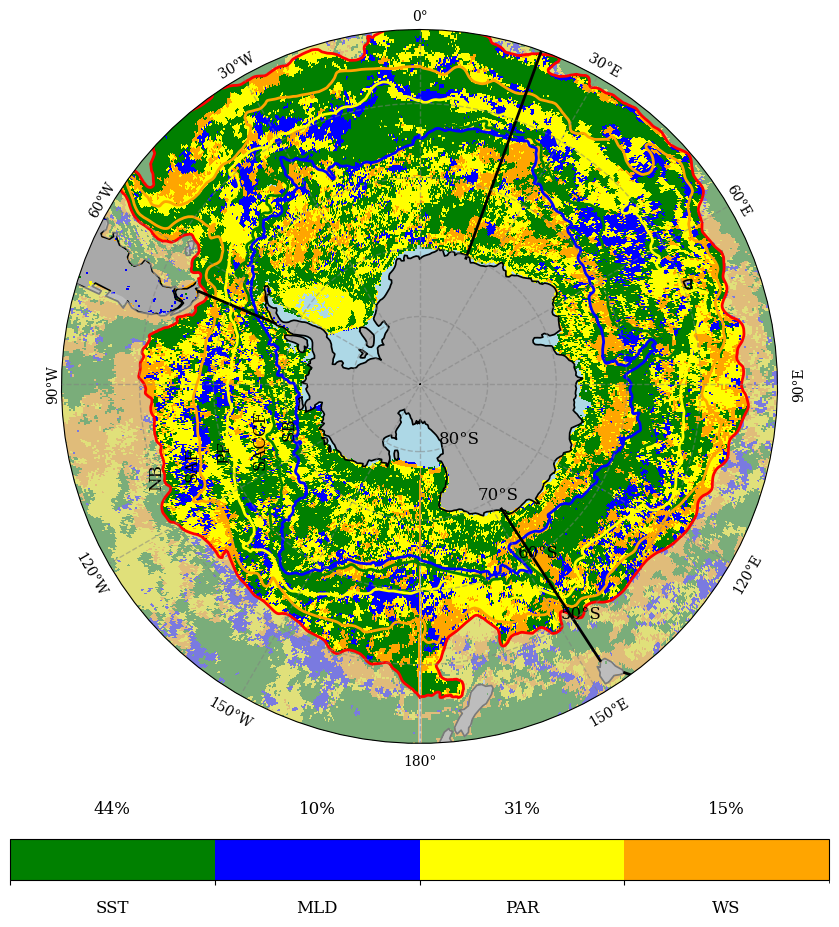

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

colors = ['green', 'blue', 'yellow', 'orange']
# Create a custom colormap using ListedColormap
cmap = mcolors.ListedColormap(colors)

# Create a custom normalization for the colormap
norm = mcolors.BoundaryNorm([1, 2, 3, 4, 5], cmap.N)
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12

# Set the figure size to 15x18 inches
plt.figure(figsize=(12, 10))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax = plt.gca()
ax = antarctic_map(ax)
apply_shapefile_mask(ax)
#ax.add_feature(cfeature.LAND, color='darkgrey', zorder=10)
#clevs = np.linspace(0.001, 0.8, 11)
im = ax.pcolormesh(max_source.longitude, max_source.latitude, max_source.__xarray_dataarray_variable__, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.1, orientation='horizontal', extendrect=True)
cbar.set_ticks([1,2, 3, 4])
cbar.set_ticklabels([])
for tick, label in zip(cbar.get_ticks()+0.5, ['SST', 'MLD', 'PAR', 'WS']):
    cbar.ax.text(tick, -0.5, label, ha='center', va='top', fontsize= 12)
for pos, label in zip(cbar.get_ticks()+0.5, ['44%', '10%', '31%', '15%']):
    cbar.ax.text(pos, 1.5, label, ha='center', va='bottom', fontsize=12)
cbar.ax.tick_params(labelsize=10)
plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"

# Show the plot
plt.tight_layout()
#plt.savefig('/home/ubuntu/Figure_revised/fIGURE_11.jpg', dpi=600)